# S2 | Model: Three-Tier Text-Only Comparison

Compares how accuracy and behavior differ across three levels of vision-language integration
when models answer VQA questions **without seeing the image**:

| Tier | Description |
|---|---|
| **pretrained VLM** | Full VLM — vision encoder active, blank image fed in (`blind`) |
| **lm_decoder** | Same VLM weights, vision encoder bypassed — pure text path |
| **backbone** | Standalone LLM never co-trained with a vision encoder |

**Hypothesis:** If visual pre-training introduces language shortcuts, accuracy should be
`backbone < lm_decoder ≤ pretrained VLM` under blind conditions, and the instruction
effect (`blind → inst_blind`) should be largest for models most gated by language context.

**Conditions (blind only — original condition identical for text-only tiers):**
- `blind`: no instruction, blank/no image
- `inst_blind`: + instruction to imagine an image / use language knowledge

In [1]:
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from collections import Counter, defaultdict

sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
from utils.constants import (
    ABSTAIN_TOKENS,
    BB_MODELS,
    CONDITIONS,
    CONTROL_TYPES,
    CT_LABELS,
    LM_MODELS,
    TIER_COLORS,
    TIER_ORDER,
    TIER_STYLE,
    TRIPLES,
    VLM_MODELS,
)
from utils.load_session import clean_answer
from utils.vqa import VQAAnswerMapper, vqa_accuracy

BASE    = Path('/home/david/Desktop/yuna/HPA/evaluation/logits')
VLM_DIR = BASE / 'pretrained'
LM_DIR  = BASE / 'lm_decoder/pretrained'
BB_DIR  = BASE / 'backbone/pretrained'
FIG_DIR = Path('/home/david/Desktop/yuna/HPA/analysis/figures')
FIG_DIR.mkdir(exist_ok=True)

mapper = VQAAnswerMapper()

def load(path):
    p = Path(path)
    if not p.exists():
        return None
    return [json.loads(l) for l in p.read_text().splitlines() if l.strip()]

def score(rows, ct='question'):
    if not rows:
        return np.nan
    return np.mean([
        vqa_accuracy(clean_answer(r['generated_answers'].get(ct, '')),
                     mapper.get_answers(r['question_id']))
        for r in rows
    ])

def abstain_rate(rows, ct='question'):
    if not rows:
        return np.nan
    return np.mean([
        any(token in clean_answer(r['generated_answers'].get(ct, '')).lower()
            for token in ABSTAIN_TOKENS)
        for r in rows
    ])

def inst_delta(blind_rows, inst_rows, ct='question'):
    if not blind_rows or not inst_rows:
        return np.nan
    return score(inst_rows, ct) - score(blind_rows, ct)

print('Dirs exist:', VLM_DIR.exists(), LM_DIR.exists(), BB_DIR.exists())
print(f'VLM models: {len(VLM_MODELS)},  VLM backbone decoder: {len(LM_MODELS)},  Backbone: {len(BB_MODELS)}')


Dirs exist: True True True
VLM models: 9,  VLM backbone decoder: 9,  Backbone: 7


## 1. Accuracy by Tier

In [2]:
# Build per-model accuracy table for all 3 tiers
rows = []
tier_map = [
    ('VLM',        VLM_DIR, VLM_MODELS),
    ('VLM backbone decoder', LM_DIR,  LM_MODELS),
    ('standalone LLM',   BB_DIR,  BB_MODELS),
]
for tier, tdir, models in tier_map:
    for model in models:
        for cond_suffix, cond_label, _ in CONDITIONS:
            r = load(tdir / model / f'vqa_1k{cond_suffix}.jsonl')
            if r is None: continue
            rows.append({
                'tier':      tier,
                'model':     model,
                'condition': cond_label,
                'acc':       score(r),
                'abstain':   abstain_rate(r),
                'n':         len(r),
            })

df = pd.DataFrame(rows)

# Tier-level summary
summary = df.groupby(['tier','condition'])['acc'].agg(['mean','std','count']).round(3)
print(summary.to_string())
print()
print(df[['tier','model','condition','acc','abstain']].to_string(index=False, float_format='%.3f'))

   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
                        mean    std  count
tier       condition                      
Backbone   blind       0.159  0.149      5
           inst_blind  0.165  0.136      5
VLM backbone decoder blind       0.382  0.032      9
           inst_blind  0.386  0.025      9
VLM        blind       0.348  0.011      9
           inst_blind  0.352  0.013      9

      tier                    model  condition   acc  abstain
       VLM     Qwen3-VL-2B-Instruct      blind 0.357    0.038
       VLM     Qwen3-VL-2B-Instruct inst_blind 0.358    0.028
       VLM     Qwen3-VL-4B-Instruct      blind 0.345    0.120
       VLM     Qwen3-VL-4B-Instruct inst_blind 0.372    0.041
       VLM     Qwen3-VL-8B-Instruct      blind 0.342    0.105
       VLM     Qwen3-VL-8B-Instruct inst_blind 0.362    0.038
       VLM           InternVL3_5-1B      blind 0.352    0.000
       VLM    

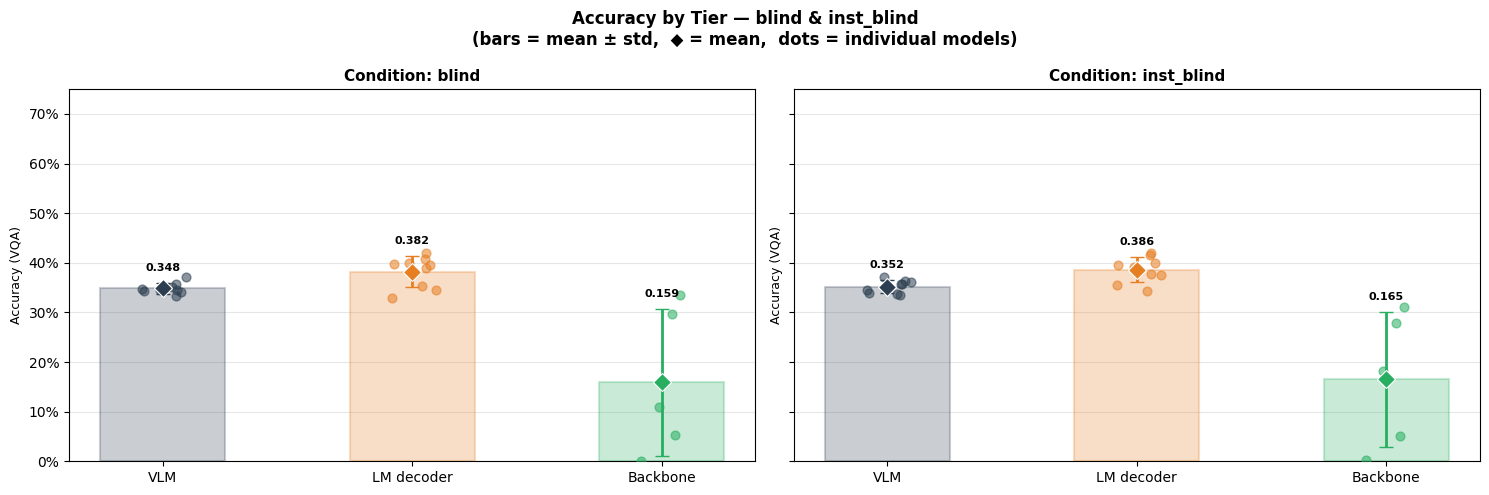

In [3]:
# ── Accuracy: individual models per tier, grouped by condition ────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

TIER_ORDER = ['VLM', 'VLM backbone decoder', 'standalone LLM']
TIER_COLORS = {'VLM': '#2c3e50', 'VLM backbone decoder': '#e67e22', 'standalone LLM': '#27ae60'}

for ax, (_, cond_label, _) in zip(axes, CONDITIONS):
    sub = df[df.condition == cond_label]

    for tier in TIER_ORDER:
        t = sub[sub.tier == tier]
        jitter = np.random.default_rng(42).uniform(-0.1, 0.1, len(t))
        x = TIER_ORDER.index(tier)
        ax.scatter([x + j for j in jitter], t['acc'],
                   color=TIER_COLORS[tier], alpha=0.55, s=40, zorder=3)
        # Mean bar + error
        m, s_ = t['acc'].mean(), t['acc'].std()
        ax.bar(x, m, 0.5, color=TIER_COLORS[tier], alpha=0.25,
               edgecolor=TIER_COLORS[tier], linewidth=1.5, zorder=2)
        ax.errorbar(x, m, yerr=s_, fmt='none',
                    color=TIER_COLORS[tier], capsize=5, lw=2, zorder=4)
        # Diamond marker for mean
        ax.plot(x, m, marker='D', markersize=9, color=TIER_COLORS[tier],
                markeredgecolor='white', markeredgewidth=0.8, zorder=5)
        ax.text(x, m + s_ + 0.02, f'{m:.3f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

    ax.set_xticks(range(len(TIER_ORDER)))
    ax.set_xticklabels(TIER_ORDER, fontsize=10)
    ax.set_ylabel('Accuracy (VQA)', fontsize=9)
    ax.set_ylim(0, 0.75)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(f'Condition: {cond_label}', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Accuracy by Tier — blind & inst_blind\n'
             '(bars = mean ± std,  ◆ = mean,  dots = individual models)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'tier_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Degradation Ladder by Tier

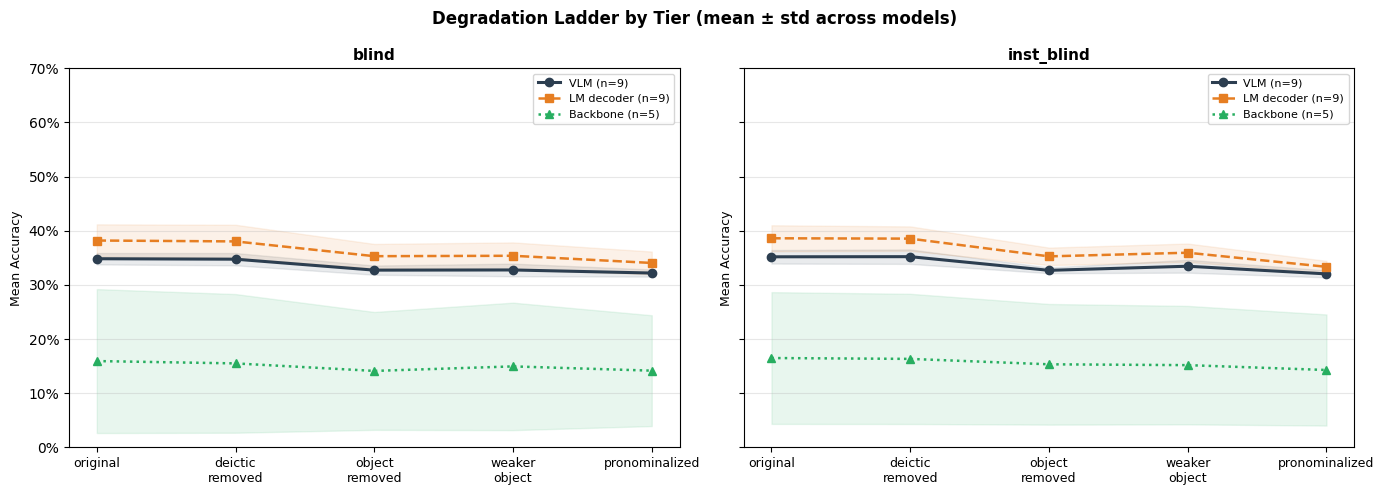

In [4]:
# ── Mean degradation ladder per tier, blind and inst_blind ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (cond_suffix, cond_label, _) in zip(axes, CONDITIONS):
    for tier, tdir, models in tier_map:
        st = TIER_STYLE[tier]
        all_accs = []
        for model in models:
            rows_ = load(tdir / model / f'vqa_1k{cond_suffix}.jsonl')
            if not rows_: continue
            all_accs.append([score(rows_, ct) for ct in CONTROL_TYPES])
        if not all_accs: continue
        mean_accs = np.nanmean(all_accs, axis=0)
        std_accs  = np.nanstd(all_accs,  axis=0)
        x = range(len(CONTROL_TYPES))
        ax.plot(x, mean_accs, color=st['color'], ls=st['ls'], lw=st['lw'],
                marker=st['marker'], markersize=6, label=f"{tier} (n={len(all_accs)})", zorder=4)
        ax.fill_between(x, mean_accs - std_accs, mean_accs + std_accs,
                        color=st['color'], alpha=0.10)

    ax.set_xticks(range(len(CONTROL_TYPES)))
    ax.set_xticklabels(CT_LABELS, fontsize=9)
    ax.set_ylabel('Mean Accuracy', fontsize=9)
    ax.set_ylim(0, 0.7)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(f'{cond_label}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Degradation Ladder by Tier (mean ± std across models)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'tier_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Instruction Effect: Blind → Inst_Blind

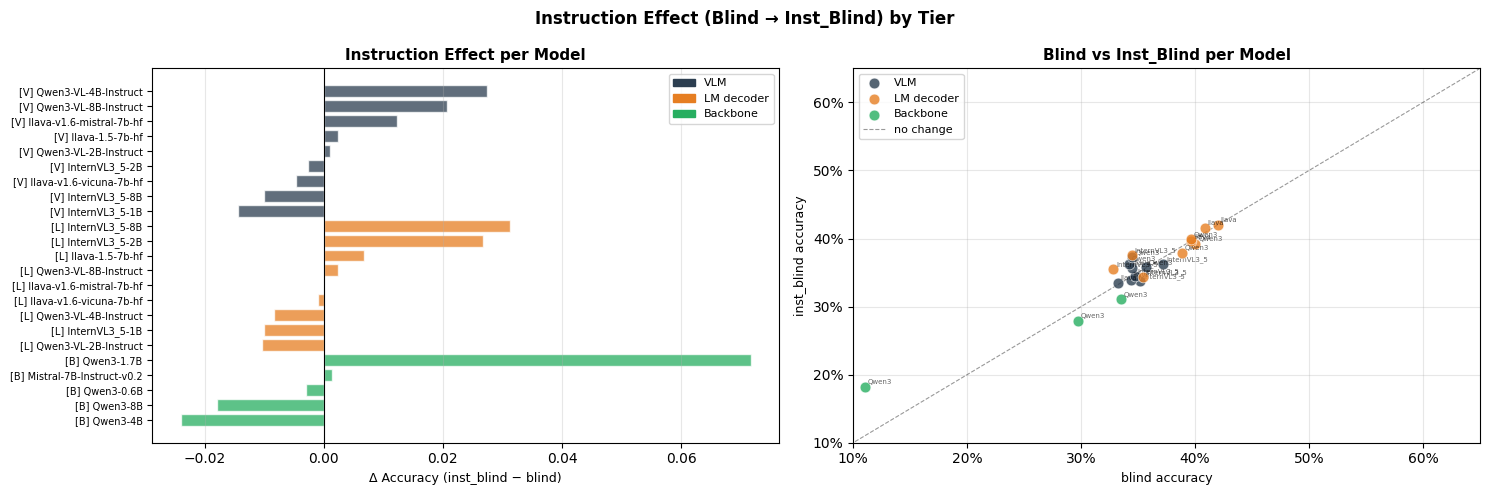


Mean Δacc by tier:
             mean    std  count
tier                           
Backbone    0.006  0.038      5
VLM backbone decoder  0.004  0.015      9
VLM         0.004  0.014      9


In [5]:
# ── Δacc (inst_blind − blind) per model, colored by tier ─────────────────────
delta_rows = []
for tier, tdir, models in tier_map:
    for model in models:
        b = load(tdir / model / 'vqa_1k_control_blind.jsonl')
        i = load(tdir / model / 'vqa_1k_control_inst_blind.jsonl')
        if b is None or i is None: continue
        delta_rows.append({'tier': tier, 'model': model, 'delta': score(i) - score(b),
                           'blind': score(b), 'inst': score(i)})

ddf = pd.DataFrame(delta_rows).sort_values(['tier','delta'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: delta bar per model, grouped by tier
ax = axes[0]
colors_ = [TIER_COLORS[r['tier']] for _, r in ddf.iterrows()]
bars = ax.barh(range(len(ddf)), ddf['delta'], color=colors_, alpha=0.75, edgecolor='white')
ax.axvline(0, color='k', lw=0.8)
ax.set_yticks(range(len(ddf)))
ax.set_yticklabels([f"[{r['tier'][0]}] {r['model']}" for _, r in ddf.iterrows()], fontsize=7)
ax.set_xlabel('Δ Accuracy (inst_blind − blind)', fontsize=9)
ax.set_title('Instruction Effect per Model', fontsize=11, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=TIER_COLORS[t], label=t) for t in TIER_ORDER], fontsize=8)
ax.grid(axis='x', alpha=0.3)

# Right: scatter blind vs inst_blind, colored by tier
ax = axes[1]
for tier in TIER_ORDER:
    t = ddf[ddf.tier == tier]
    ax.scatter(t['blind'], t['inst'], color=TIER_COLORS[tier], s=60,
               alpha=0.8, label=tier, edgecolors='white', linewidths=0.5, zorder=3)
    for _, r in t.iterrows():
        ax.annotate(r['model'].split('-')[0], (r['blind'], r['inst']),
                    fontsize=5, alpha=0.6, xytext=(2, 2), textcoords='offset points')
ax.plot([0,1],[0,1],'k--', lw=0.8, alpha=0.4, label='no change')
ax.set_xlabel('blind accuracy', fontsize=9)
ax.set_ylabel('inst_blind accuracy', fontsize=9)
ax.set_xlim(0.1, 0.65); ax.set_ylim(0.1, 0.65)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Blind vs Inst_Blind per Model', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('Instruction Effect (Blind → Inst_Blind) by Tier', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'tier_inst_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMean Δacc by tier:')
print(ddf.groupby('tier')['delta'].agg(['mean','std','count']).round(3))

## 4. Soft Abstention by Tier

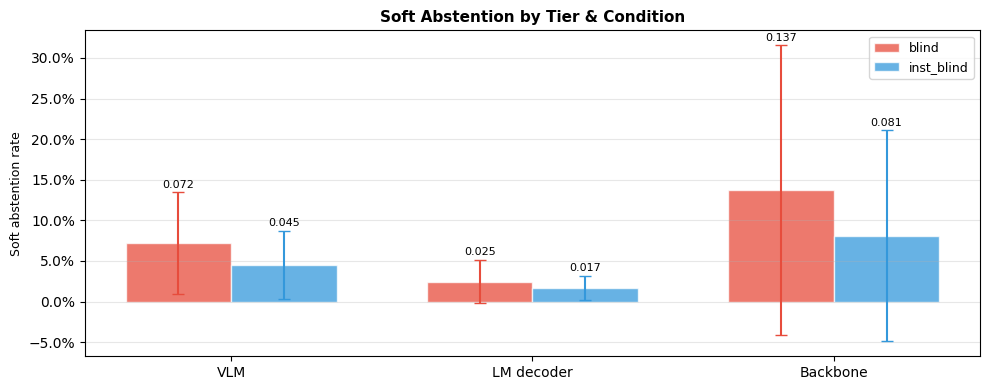

In [6]:
# ── Soft abstention: tier × condition ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

x = np.arange(len(TIER_ORDER))
w = 0.35
cond_colors = {'blind': '#e74c3c', 'inst_blind': '#3498db'}

for ci, (_, cond_label, _) in enumerate(CONDITIONS):
    means, stds = [], []
    for tier in TIER_ORDER:
        t = df[(df.tier == tier) & (df.condition == cond_label)]
        means.append(t['abstain'].mean())
        stds.append(t['abstain'].std())
    offset = (ci - 0.5) * w
    bars = ax.bar(x + offset, means, w, label=cond_label,
                  color=cond_colors[cond_label], alpha=0.75, edgecolor='white')
    ax.errorbar(x + offset, means, yerr=stds, fmt='none',
                color=cond_colors[cond_label], capsize=4, lw=1.5)
    for xi, (m, s_) in zip(x + offset, zip(means, stds)):
        ax.text(xi, m + s_ + 0.003, f'{m:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(TIER_ORDER, fontsize=10)
ax.set_ylabel('Soft abstention rate', fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Soft Abstention by Tier & Condition', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'tier_abstention.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Paired Comparison: Same Language Model Across Tiers

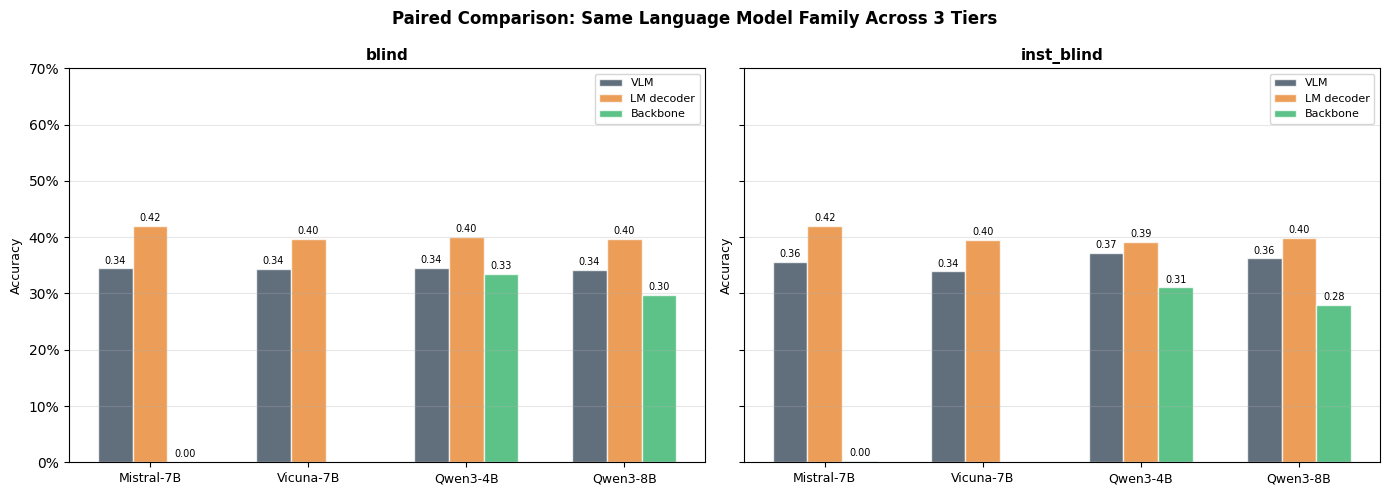

In [7]:
# ── Direct comparison: same LM backbone across 3 tiers ───────────────────────
# TRIPLES = (vlm_model, lm_model, bb_model, label)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (_, cond_label, cond_color) in zip(axes, CONDITIONS):
    cond_suffix = '_control_blind' if cond_label == 'blind' else '_control_inst_blind'
    n = len(TRIPLES)
    x = np.arange(n)
    w = 0.22

    tier_offsets = {'VLM': -w, 'VLM backbone decoder': 0, 'standalone LLM': w}
    tier_dirs    = {'VLM': VLM_DIR, 'VLM backbone decoder': LM_DIR, 'standalone LLM': BB_DIR}
    triple_keys  = {'VLM': 0, 'VLM backbone decoder': 1, 'standalone LLM': 2}

    for tier, offset in tier_offsets.items():
        accs = []
        for vlm_m, lm_m, bb_m, label in TRIPLES:
            model = [vlm_m, lm_m, bb_m][triple_keys[tier]]
            rows_ = load(tier_dirs[tier] / model / f'vqa_1k{cond_suffix}.jsonl')
            accs.append(score(rows_) if rows_ else np.nan)
        ax.bar(x + offset, accs, w, label=tier,
               color=TIER_COLORS[tier], alpha=0.75, edgecolor='white')
        for xi, a in zip(x + offset, accs):
            if not np.isnan(a):
                ax.text(xi, a + 0.005, f'{a:.2f}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels([t[3] for t in TRIPLES], fontsize=9)
    ax.set_ylabel('Accuracy', fontsize=9)
    ax.set_ylim(0, 0.7)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(f'{cond_label}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Paired Comparison: Same Language Model Family Across 3 Tiers',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'tier_paired.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary Table

In [8]:
# ── Per-model accuracy table + tier-level aggregates ─────────────────────────
print('=== Per-model ===')
print(df[['tier','model','condition','acc','abstain']]
      .sort_values(['tier','condition','acc'], ascending=[True,True,False])
      .to_string(index=False, float_format='%.3f'))

print('\n=== Tier × Condition averages ===')
agg = df.groupby(['tier','condition']).agg(
    n_models   = ('model','nunique'),
    mean_acc   = ('acc','mean'),
    std_acc    = ('acc','std'),
    mean_abst  = ('abstain','mean'),
).round(3)
print(agg.to_string())

=== Per-model ===
      tier                    model  condition   acc  abstain
  Backbone                 Qwen3-4B      blind 0.335    0.017
  Backbone                 Qwen3-8B      blind 0.297    0.112
  Backbone               Qwen3-1.7B      blind 0.110    0.116
  Backbone               Qwen3-0.6B      blind 0.053    0.000
  Backbone Mistral-7B-Instruct-v0.2      blind 0.001    0.442
  Backbone                 Qwen3-4B inst_blind 0.311    0.005
  Backbone                 Qwen3-8B inst_blind 0.279    0.038
  Backbone               Qwen3-1.7B inst_blind 0.182    0.051
  Backbone               Qwen3-0.6B inst_blind 0.050    0.000
  Backbone Mistral-7B-Instruct-v0.2 inst_blind 0.003    0.310
VLM backbone decoder llava-v1.6-mistral-7b-hf      blind 0.420    0.022
VLM backbone decoder          llava-1.5-7b-hf      blind 0.409    0.026
VLM backbone decoder     Qwen3-VL-4B-Instruct      blind 0.400    0.014
VLM backbone decoder  llava-v1.6-vicuna-7b-hf      blind 0.397    0.022
VLM backbone

## 7. VLM vs LM-Decoder: Answer Divergence and Logit Comparison

Do VLM and VLM backbone decoder give the same answers when run text-only (inst_blind)?
If answers differ, the vision encoder is shifting the language model's prior even without an image.

In [9]:
# ── Answer agreement between VLM and VLM backbone decoder (inst_blind) ─────────────────
# For each matched pair in TRIPLES, compute % identical answers across control types

agree_rows = []
for vlm_m, lm_m, bb_m, label in TRIPLES:
    vlm_rows = load(VLM_DIR / vlm_m / 'vqa_1k_control_inst_blind.jsonl')
    lmd_rows = load(LM_DIR  / lm_m  / 'vqa_1k_control_inst_blind.jsonl')
    if not vlm_rows or not lmd_rows: continue

    vlm_map = {r['question_id']: r for r in vlm_rows}
    lmd_map = {r['question_id']: r for r in lmd_rows}
    shared  = set(vlm_map) & set(lmd_map)

    for ct in CONTROL_TYPES:
        same, total = 0, 0
        for qid in shared:
            v = clean_answer(vlm_map[qid]['generated_answers'].get(ct, ''))
            l = clean_answer(lmd_map[qid]['generated_answers'].get(ct, ''))
            if v and l:
                same  += int(v == l)
                total += 1
        if total:
            agree_rows.append({'model': label, 'ct': ct,
                               'agreement': same / total, 'n': total})

agree_df = pd.DataFrame(agree_rows)
pivot    = agree_df.pivot(index='model', columns='ct', values='agreement')[CONTROL_TYPES]

print('Answer agreement rate — VLM vs VLM backbone decoder (inst_blind)')
print(pivot.round(3).to_string())
print()
print(f'Mean across all CTs: {agree_df["agreement"].mean():.3f}')


Answer agreement rate — VLM vs VLM backbone decoder (inst_blind)
ct          question  deictic_removed  object_removed  weaker_object  pronominalized
model                                                                               
Mistral-7B     0.555            0.563           0.488          0.538           0.401
Qwen3-4B       0.521            0.534           0.428          0.495           0.321
Qwen3-8B       0.553            0.566           0.475          0.541           0.409
Vicuna-7B      0.399            0.394           0.362          0.378           0.295

Mean across all CTs: 0.461


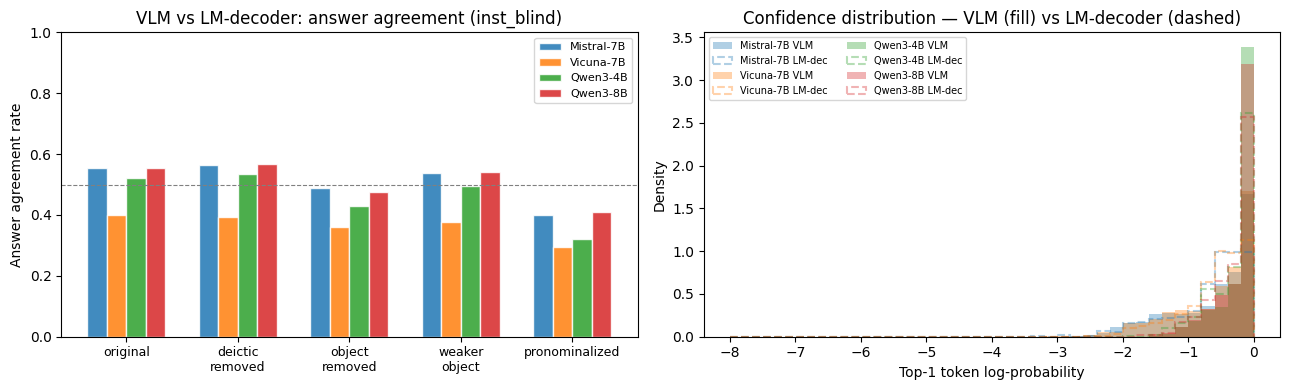

In [10]:
# ── Visualise agreement rate + top-logprob confidence ─────────────────────────
import math

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: agreement rate per control type × model pair
ax = axes[0]
x  = np.arange(len(CONTROL_TYPES))
w  = 0.7 / len(TRIPLES)
offsets = np.linspace(-(len(TRIPLES)-1)/2, (len(TRIPLES)-1)/2, len(TRIPLES)) * w
cmap = plt.get_cmap('tab10')

for i, (_, _, _, label) in enumerate(TRIPLES):
    sub = agree_df[agree_df['model'] == label].set_index('ct')
    vals = [sub.loc[ct, 'agreement'] if ct in sub.index else np.nan for ct in CONTROL_TYPES]
    ax.bar(x + offsets[i], vals, w, label=label, color=cmap(i), alpha=0.85, edgecolor='white')

ax.set_xticks(x); ax.set_xticklabels(CT_LABELS, fontsize=9)
ax.axhline(0.5, color='gray', ls='--', lw=0.8)
ax.set_ylabel('Answer agreement rate')
ax.set_title('VLM vs VLM backbone decoder: answer agreement (inst_blind)')
ax.set_ylim(0, 1); ax.legend(fontsize=8)

# Right: top-1 logprob distribution — VLM vs VLM backbone decoder (question CT only)
ax = axes[1]
for i, (vlm_m, lm_m, _, label) in enumerate(TRIPLES):
    vlm_rows = load(VLM_DIR / vlm_m / 'vqa_1k_control_inst_blind.jsonl') or []
    lmd_rows = load(LM_DIR  / lm_m  / 'vqa_1k_control_inst_blind.jsonl') or []

    def top1_lps(rows, ct='question'):
        lps = []
        for r in rows:
            gl = r.get('generated_logits', {}).get(ct, {}).get('content', [])
            if gl:
                lps.append(gl[0]['logprob'])
        return lps

    v_lps = top1_lps(vlm_rows)
    l_lps = top1_lps(lmd_rows)

    color = cmap(i)
    ax.hist(v_lps, bins=40, range=(-8, 0), density=True, alpha=0.35,
            color=color, label=f'{label} VLM')
    ax.hist(l_lps, bins=40, range=(-8, 0), density=True, alpha=0.35,
            color=color, histtype='step', lw=1.5, linestyle='--',
            label=f'{label} LM-dec')

ax.set_xlabel('Top-1 token log-probability'); ax.set_ylabel('Density')
ax.set_title('Confidence distribution — VLM (fill) vs VLM backbone decoder (dashed)')
ax.legend(fontsize=7, ncol=2)

plt.tight_layout(); plt.show()


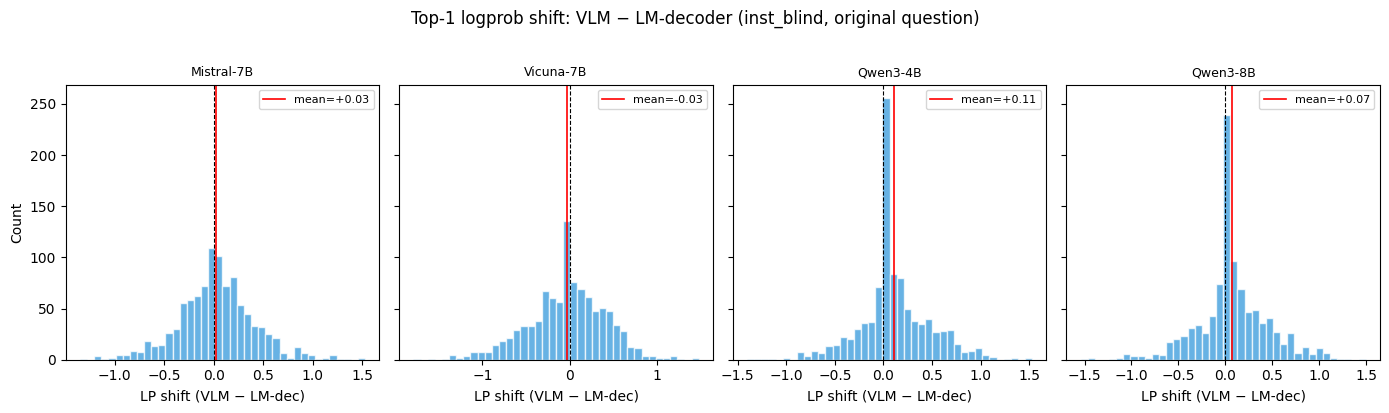

In [11]:
# ── Per-question logprob shift: VLM − VLM backbone decoder ──────────────────────────────
# For each question, how much does removing the vision encoder shift
# top-1 token confidence?  Positive = VLM more confident, Negative = LM-dec more confident

fig, axes = plt.subplots(1, len(TRIPLES), figsize=(14, 4), sharey=True)

for ax, (vlm_m, lm_m, _, label) in zip(axes, TRIPLES):
    vlm_rows = load(VLM_DIR / vlm_m / 'vqa_1k_control_inst_blind.jsonl') or []
    lmd_rows = load(LM_DIR  / lm_m  / 'vqa_1k_control_inst_blind.jsonl') or []
    vlm_map  = {r['question_id']: r for r in vlm_rows}
    lmd_map  = {r['question_id']: r for r in lmd_rows}

    shifts = []
    for qid in set(vlm_map) & set(lmd_map):
        v_gl = vlm_map[qid].get('generated_logits',{}).get('question',{}).get('content',[])
        l_gl = lmd_map[qid].get('generated_logits',{}).get('question',{}).get('content',[])
        if v_gl and l_gl:
            shifts.append(v_gl[0]['logprob'] - l_gl[0]['logprob'])

    ax.hist(shifts, bins=40, color='#3498db', alpha=0.75, edgecolor='white')
    ax.axvline(0,    color='black', lw=0.8, ls='--')
    ax.axvline(np.mean(shifts), color='red', lw=1.2,
               label=f'mean={np.mean(shifts):+.2f}')
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('LP shift (VLM − LM-dec)')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Count')
plt.suptitle('Top-1 logprob shift: VLM − VLM backbone decoder (inst_blind, original question)', y=1.02)
plt.tight_layout(); plt.show()


In [12]:
# ── Examples: questions where VLM and VLM backbone decoder disagree most ────────────────
from utils.vqa import VQAAnswerMapper

_mapper = VQAAnswerMapper()
ctrl    = {int(json.loads(l)['question_id']): json.loads(l)
           for l in open(Path('/home/david/Desktop/yuna/HPA') /
                         'dataset/vqa/vqa1k_control.jsonl')}

print('=== Top disagreements (VLM vs VLM backbone decoder, inst_blind, question CT) ===\n')
for vlm_m, lm_m, _, label in TRIPLES[:2]:  # show first 2 pairs
    vlm_rows = load(VLM_DIR / vlm_m / 'vqa_1k_control_inst_blind.jsonl') or []
    lmd_rows = load(LM_DIR  / lm_m  / 'vqa_1k_control_inst_blind.jsonl') or []
    vlm_map  = {r['question_id']: r for r in vlm_rows}
    lmd_map  = {r['question_id']: r for r in lmd_rows}

    diffs = []
    for qid in set(vlm_map) & set(lmd_map):
        v_ans = clean_answer(vlm_map[qid]['generated_answers'].get('question',''))
        l_ans = clean_answer(lmd_map[qid]['generated_answers'].get('question',''))
        if v_ans.lower() == l_ans.lower(): continue
        gt    = _mapper.get_answers(qid)
        v_acc = vqa_accuracy(v_ans, gt)
        l_acc = vqa_accuracy(l_ans, gt)
        v_gl  = vlm_map[qid].get('generated_logits',{}).get('question',{}).get('content',[])
        l_gl  = lmd_map[qid].get('generated_logits',{}).get('question',{}).get('content',[])
        v_lp  = v_gl[0]['logprob'] if v_gl else 0
        l_lp  = l_gl[0]['logprob'] if l_gl else 0
        diffs.append((abs(v_lp - l_lp), qid, v_ans, l_ans, gt[:3], v_acc, l_acc, v_lp, l_lp))

    diffs.sort(reverse=True)
    print(f'--- {label} (top 8 by LP shift) ---')
    for _, qid, v, l, gt, v_acc, l_acc, v_lp, l_lp in diffs[:8]:
        q = ctrl.get(qid, {}).get('question', '')[:55]
        print(f'  qid={qid}  "{q}"')
        print(f'    GT={gt}')
        print(f'    VLM:    {v!r:20}  acc={v_acc:.1f}  lp={v_lp:.2f}')
        print(f'    LM-dec: {l!r:20}  acc={l_acc:.1f}  lp={l_lp:.2f}')
    print()


=== Top disagreements (VLM vs VLM backbone decoder, inst_blind, question CT) ===

   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
--- Mistral-7B (top 8 by LP shift) ---
  qid=16631021  "What does the sign say?"
    GT=['zone', 'zone', 'zone']
    VLM:    "The image you've provided is completely black, which makes it impossible to discern any text or signs. If you have a specific image in mind that you'd like to know about, please provide it so I can assist you."  acc=0.0  lp=-0.14
    LM-dec: 'No sign'             acc=0.0  lp=-1.66
  qid=562622004  "What does it say on the large billboard?"
    GT=['texas thank you', 'bud', 'bud']
    VLM:    'Nothing'             acc=0.0  lp=-0.34
    LM-dec: "I don't know what it says on the billboard."  acc=0.0  lp=-1.59
  qid=519471003  "What is the name on the banner?"
    GT=['ack hostingcom', 'jack hostingcom', 'ack hosting']
    VLM:    'No banner'           